# WAC EDR to `framestitch`: a step-by-step ISIS pipeline walkthrough

Walks through ISIS3's EDR-to-`framestitch` pipeline for one real WAC product, with each
intermediate cube displayed inline. Stops after `framestitch` -- reprojection is
`isis_wac.run_cam2map_for_crop`'s job, not covered here. See
`../docs/data-sources/lroc-wac-edr-cdr.md` for what the framelet-boundary striping visible in the
stitched cube actually is.

In [1]:
import numpy as np
import rasterio.windows

import trntest
from trntest import isis_wac, plotting

config = trntest.load_config()
print(f"edr_product={config.edr_product} edr_volume={config.edr_volume} target_frame_index={config.target_frame_index}")

edr_product=M1329714703CE edr_volume=LROLRC_0041C target_frame_index=440


This is `config.py`'s zero-argument default product (`M1329714703CE`) -- no `dataclasses.replace`
needed to target it. Its `camera.boresight_rotation_k` is `+1` (non-mirrored pass); `flip=false`
is the visually-correct `framestitch` value for this product (the reverse, `flip=true`, produces
scrambled/banded garbage). Hardcoded below rather than recomputed, since recomputing it would mean
furnishing SPICE kernels this notebook otherwise doesn't need at all.

In [2]:
FLIP = False

## Step 0: ISIS reference data + EDR fetch

`isis_wac.ensure_isisdata()` is a one-time, lazily-skipped fetch (~5GB total: `base` +
`--no-kernels`, `lro` + `--no-kernels` -- `spiceinit web=yes` below covers the pointing/position
role that would otherwise need the much larger, un-flagged `base` download). `isis_wac.fetch_edr_img()`
pulls the EDR's own `.IMG` pixel data (not the `.xml` label the main demo pipeline already fetches,
and not CDR pixel data -- nothing in this project fetches that any more) through the same
`cache.fetch_lroc_file` mirror-and-skip pattern as everything else in this repo.

In [3]:
isis_wac.ensure_isisdata(config)
edr = isis_wac.fetch_edr_img(config)
edr

EdrFetchResult(img_path=PosixPath('/workspace/cache/LRO-L-LROC-2-EDR-V1.0/LROLRC_0041C/DATA/ESM4/2019334/WAC/M1329714703CE.IMG'))

## Step 1: `lrowac2isis` -- split into even/odd x UV/VIS cubes

Splits the EDR into 4 cubes. The VIS cubes come out already band-separated (5 ISIS cube bands,
one per VIS filter) -- no manual byte-offset extraction against the raw CDR needed at all. Only
the VIS cubes matter here; the UV cubes are never touched below.

In [4]:
split = isis_wac.run_lrowac2isis(edr, config)
split

Lrowac2IsisResult(uv_even=PosixPath('/workspace/output/isis/M1329714703CE.uv.even.cub'), vis_even=PosixPath('/workspace/output/isis/M1329714703CE.vis.even.cub'), uv_odd=PosixPath('/workspace/output/isis/M1329714703CE.uv.odd.cub'), vis_odd=PosixPath('/workspace/output/isis/M1329714703CE.vis.odd.cub'))

Raw split cubes, band 1 -- also confirms `rasterio`/GDAL reads `.cub` files directly (via ASP's
own bundled GDAL).

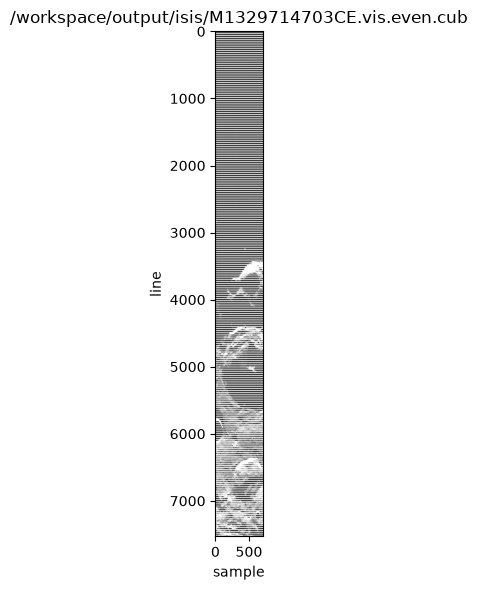

In [5]:
_ = plotting.plot_raster(split.vis_even)

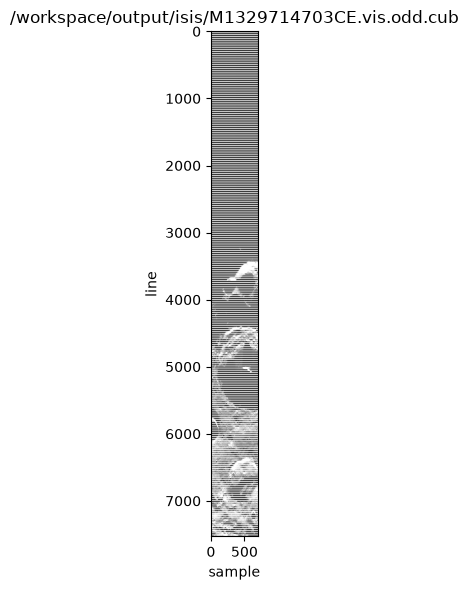

In [6]:
_ = plotting.plot_raster(split.vis_odd)

## Step 2: `spiceinit web=yes` -- attach real SPICE geometry, zero local kernels required

Edits each cube's label in place (no new file, no re-display needed) -- works for WAC (not just
NAC) with zero local kernel files fetched.

In [7]:
even_spice = isis_wac.run_spiceinit(split.vis_even, config)
odd_spice = isis_wac.run_spiceinit(split.vis_odd, config)

## Step 3: `lrowaccal` -- radiometric calibration

In [8]:
even_cal = isis_wac.run_lrowaccal(even_spice, config)
odd_cal = isis_wac.run_lrowaccal(odd_spice, config)

## Step 4: `framestitch` -- combine even + odd

Combines the even/odd parity cubes into one. `flip=False` per the hardcoded value above.

In [9]:
stitched = isis_wac.run_framestitch(even_cal, odd_cal, flip=FLIP, config=config)
stitched

FramestitchResult(cub_path=PosixPath('/workspace/output/isis/M1329714703CE.vis.cal.stitched.cub'), flip=False)

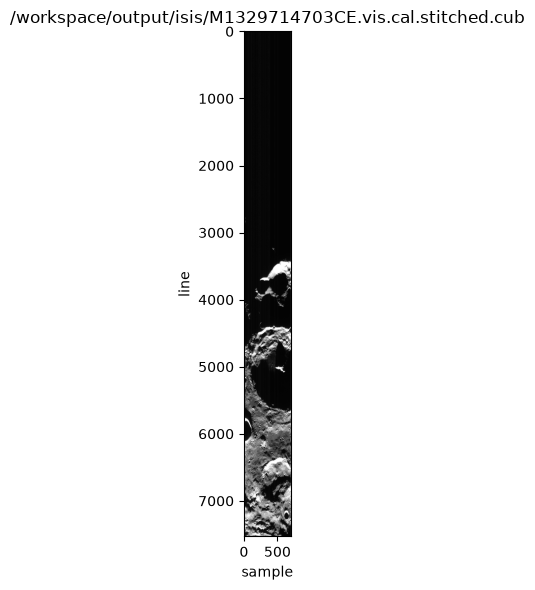

In [10]:
_ = plotting.plot_raster(stitched.cub_path)

### Zoomed crop near framelet boundaries

The exact framelet period in *this* (post-`lrowac2isis`) cube's own line coordinates isn't
established -- the raw CDR's 78-lines/frame figure describes that file's own *pre*-TDI-extraction
byte layout, not this already-TDI-processed ISIS cube. Rather than guess a line range (the swath's
early lines tend to be shadowed), pick the
window with real signal data-drivenly: read the whole band, find the `WINDOW_HEIGHT`-line span
with the highest mean value (a cheap proxy for "not near-empty/shadowed"), and crop there.

selected line window (peak mean signal): 6339:7339 of 7532


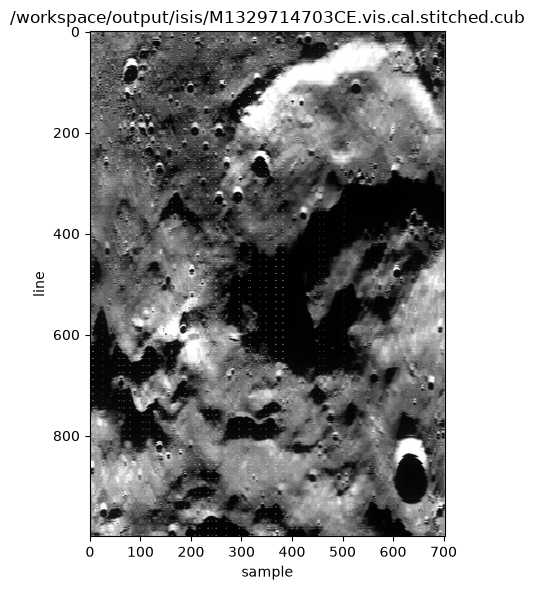

In [11]:
WINDOW_HEIGHT = 1000

full_band = plotting.read_raster_band(stitched.cub_path)

valid = plotting.valid_pixel_mask(full_band)
row_means = np.nan_to_num(np.nanmean(np.where(valid, full_band, np.nan), axis=1))
window_sums = np.convolve(row_means, np.ones(WINDOW_HEIGHT), mode="valid")
line_start = int(np.argmax(window_sums))
line_end = line_start + WINDOW_HEIGHT
print(f"selected line window (peak mean signal): {line_start}:{line_end} of {full_band.shape[0]}")

window = rasterio.windows.Window(col_off=0, row_off=line_start, width=704, height=WINDOW_HEIGHT)
_ = plotting.plot_raster(stitched.cub_path, window=window)